In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
np.set_printoptions(legacy='1.25')

In [2]:
plt.rcParams["figure.figsize"] = [16, 9]
# plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["font.family"] = "serif"

In [3]:
FONT_SIZE_TITLE_PLOT = 48  # 40
FONT_SIZE_TITLE_AX = 36  # 30
FONT_SIZE_LABEL = 30  # 24
FONT_SIZE_TICKS = 24  # 20
FONT_SIZE_LEGEND = 32  # 28

In [4]:
stock_names = ["PEP", "KO", "NVDA", "KSU"]
n_stocks = len(stock_names)

In [5]:
seed = 42
id = "v56u7ulz"
epoch = 284
i = 0

In [6]:
with open(f'storage/{id}/synthetic/epoch={epoch}/sample.pkl', 'rb') as f:
    d = pickle.load(f)
price_real = d['x_price']
volume_real = d['x_volume']
price_pred = d['x_hat_price']
volume_pred = d['x_hat_volume']
price_real.shape, volume_real.shape, price_pred.shape, volume_pred.shape

((4, 9359), (4, 9359), (4, 9359), (4, 9359))

In [7]:
price_real = np.concat((price_real[:, [0]], price_real), axis=1)
volume_real = np.concat((volume_real[:, [0]], volume_real), axis=1)
price_pred = np.concat((price_pred[:, [0]], price_pred), axis=1)
volume_pred = np.concat((volume_pred[:, [0]], volume_pred), axis=1)
price_real.shape, volume_real.shape, price_pred.shape, volume_pred.shape

((4, 9360), (4, 9360), (4, 9360), (4, 9360))

In [8]:
price_real = price_real / 10000
price_pred = price_pred / 10000

price_real.shape, price_pred.shape, volume_real.shape, volume_pred.shape

((4, 9360), (4, 9360), (4, 9360), (4, 9360))

In [9]:
history_indexes = np.arange(390)
continuation_indexes = np.arange(390, price_real.shape[1])
history_indexes.shape, continuation_indexes.shape

((390,), (8970,))

# Prices

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

add_label = True
for (ax, stock_name, real, synthetic) in zip(axes, stock_names, price_real, price_pred):
    ax.plot(history_indexes, real[:390], color="C0", label="Observed" if add_label else None)
    ax.plot(continuation_indexes, real[390:], color="C1", label="Real" if add_label else None)
    ax.plot(continuation_indexes, synthetic[390:], color="C2", label="Synthetic" if add_label else None)
    ax.axvline(x=390, color="r")

    ax.set_title(stock_name, fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel("Steps", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Price ($)", fontsize=FONT_SIZE_LABEL, rotation=90)
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.set_xticks(list(ax.get_xticks()[2:-1]) + [390])

    add_label = False

# fig.suptitle("Prices", fontsize=FONT_SIZE_TITLE_PLOT, y=1)
fig.legend(
    loc="upper center",
    ncol=3,
    fontsize=FONT_SIZE_LEGEND,
    frameon=False,
    # bbox_to_anchor=(0.5, 1.07)
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig('plots/prices.pdf')
# plt.show()
plt.close(fig)

# Couples

In [12]:
df_corr_real = pd.DataFrame(price_real.T, columns=stock_names).corr().round(2)
df_corr_synthetic = pd.DataFrame(price_pred.T, columns=stock_names).corr().round(2)
df_corr_real, df_corr_synthetic

(       PEP    KO  NVDA   KSU
 PEP   1.00  0.94 -0.66 -0.52
 KO    0.94  1.00 -0.81 -0.56
 NVDA -0.66 -0.81  1.00  0.65
 KSU  -0.52 -0.56  0.65  1.00,
        PEP    KO  NVDA   KSU
 PEP   1.00  0.90 -0.56 -0.65
 KO    0.90  1.00 -0.31 -0.32
 NVDA -0.56 -0.31  1.00  0.76
 KSU  -0.65 -0.32  0.76  1.00)

In [13]:
np.mean((df_corr_real-df_corr_synthetic)**2)

0.043525

In [14]:
minutes_in_a_day = 6 * 60 + 30
minutes_in_a_day

390

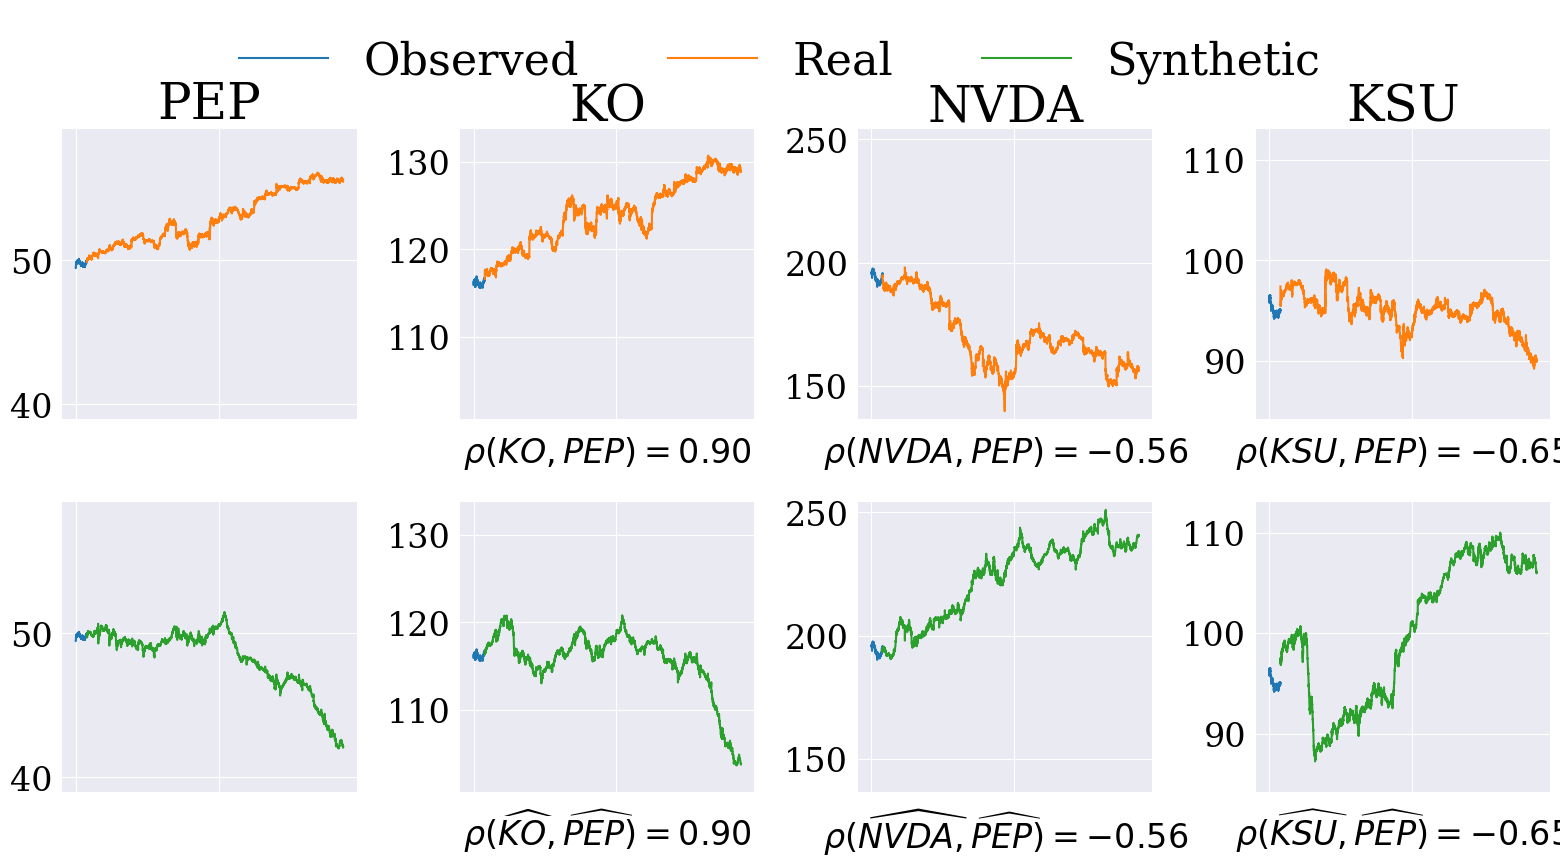

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

add_label = True
for i, (ax_real, ax_synthetic) in enumerate(axes.T):
    stock_name, real, synthetic = stock_names[i], price_real[i], price_pred[i]

    ylim = (min(real.min(), synthetic.min())-3, max(real.max(), synthetic.max())+3)
    ax_real.set_ylim(ylim)
    ax_synthetic.set_ylim(ylim)
    ax_real.set_xticklabels([])
    ax_synthetic.set_xticklabels([])
    ax_real.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax_synthetic.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

    ax_real.plot(history_indexes, real[:minutes_in_a_day], color="C0", label="Observed" if add_label else None)
    ax_real.plot(continuation_indexes, real[minutes_in_a_day:], color="C1", label="Real" if add_label else None)

    ax_synthetic.plot(history_indexes, synthetic[:minutes_in_a_day], color="C0")
    ax_synthetic.plot(
        continuation_indexes, synthetic[minutes_in_a_day:], color="C2", label="Synthetic" if add_label else None
    )

    ax_real.set_title(stock_name, fontsize=FONT_SIZE_TITLE_AX)

    add_label = False

    if i > 0:
        corr_real, corr_synthetic = df_corr_real[stock_name]["PEP"], df_corr_synthetic[stock_name]["PEP"]
        ax_real.set_xlabel(rf"$\rho({stock_name}, PEP)={'{:.2f}'.format(corr_synthetic)}$", fontsize=FONT_SIZE_LABEL - 6)
        ax_synthetic.set_xlabel(
            r"$\rho(\widehat{" + stock_name + r"}, \widehat{PEP})=" + "{:.2f}".format(corr_synthetic) + r"$",
            fontsize=FONT_SIZE_LABEL - 6,
        )

for ax in axes.ravel():
    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

# fig.suptitle("Price - Correlation Dynamics", fontsize=FONT_SIZE_TITLE_PLOT, y=1)
fig.legend(
    loc="upper center",
    ncol=3,
    fontsize=FONT_SIZE_LEGEND,
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig("plots/price_correlations_wrt_PEP.pdf")
plt.show()
plt.close(fig)

# Volumes

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

add_label = True
for (
    ax,
    stock_name,
    real,
    synthetic,
) in zip(axes, stock_names, volume_real, volume_pred):
    ax.plot(history_indexes, real[:390], color="C0", label="Observed" if add_label else None)
    ax.plot(continuation_indexes, real[390:], color="C1", label="Real" if add_label else None)
    ax.plot(
        continuation_indexes,
        synthetic[390:],
        color="C2",
        alpha=0.7,
        label="Synthetic" if add_label else None,
    )
    ax.axvline(x=390, color="r")

    ax.set_title(stock_name, fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel("Steps", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Shares", fontsize=FONT_SIZE_LABEL, rotation=90)
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.set_xticks(list(ax.get_xticks()[2:-1]) + [390])

    add_label = False

    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

# fig.suptitle("Volumes", fontsize=FONT_SIZE_TITLE_PLOT, y=1)
fig.legend(
    loc="upper center",
    ncol=3,
    fontsize=FONT_SIZE_LEGEND,
    frameon=False,
    # bbox_to_anchor=(0.5, 1.06)
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/volumes.pdf")
# plt.show()
plt.close(fig)

# Stylised Facts

In [113]:
price_real = np.reshape(price_real, shape=(n_stocks, -1, minutes_in_a_day))
price_pred = np.reshape(price_pred, shape=(n_stocks, -1, minutes_in_a_day))
price_real.shape, price_pred.shape

((4, 24, 390), (4, 24, 390))

In [114]:
n_days = price_real.shape[1]
n_days

24

In [115]:
minutely_returns_real = np.diff(np.log(price_real)).reshape(n_stocks, -1)
minutely_returns_synthetic = np.diff(np.log(price_pred)).reshape(n_stocks, -1)
minutely_returns_real.shape, minutely_returns_synthetic.shape

((4, 9336), (4, 9336))

In [116]:
n_minutes = 15
n_minutely_returns_real = np.diff(np.log(price_real[:, :, ::n_minutes])).reshape(n_stocks, -1)
n_minutely_returns_synthetic = np.diff(np.log(price_pred[:, :, ::n_minutes])).reshape(n_stocks, -1)
n_minutely_returns_real.shape, n_minutely_returns_synthetic.shape

((4, 600), (4, 600))

In [117]:
xlim = (
    min(
        minutely_returns_real.min(),
        minutely_returns_synthetic.min(),
        n_minutely_returns_real.min(),
        n_minutely_returns_synthetic.min(),
    ),
    max(
        minutely_returns_real.max(),
        minutely_returns_synthetic.max(),
        n_minutely_returns_real.max(),
        n_minutely_returns_synthetic.max(),
    ),
)

In [118]:
bins = np.linspace(xlim[0], xlim[1], 75)

## Returns Distribution

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

add_label = True
for ax, stock_name, real, synthetic in zip(axes, stock_names, minutely_returns_real, minutely_returns_synthetic):
    ax.set_xlim(xlim)

    ax.hist(
        x=[synthetic, real],
        label=["Synthetic", "Real"] if add_label else None,
        color=["C2", "C1"],
        bins=bins,
        density=True,
        log=True,
        histtype="step",
        linewidth=3,
    )

    add_label = False
    ax.set_title(f"{stock_name}", fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel("Minutely Log-Returns", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Density", fontsize=FONT_SIZE_LABEL)
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

# fig.suptitle("Returns distribution", fontsize=FONT_SIZE_TITLE_PLOT, y=1.0)
fig.legend(
    loc="upper center",
    ncol=2,
    fontsize=FONT_SIZE_LEGEND,
    # bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/return_distribution.pdf")
# plt.show()
plt.close(fig)

## Aggregational Gaussianity

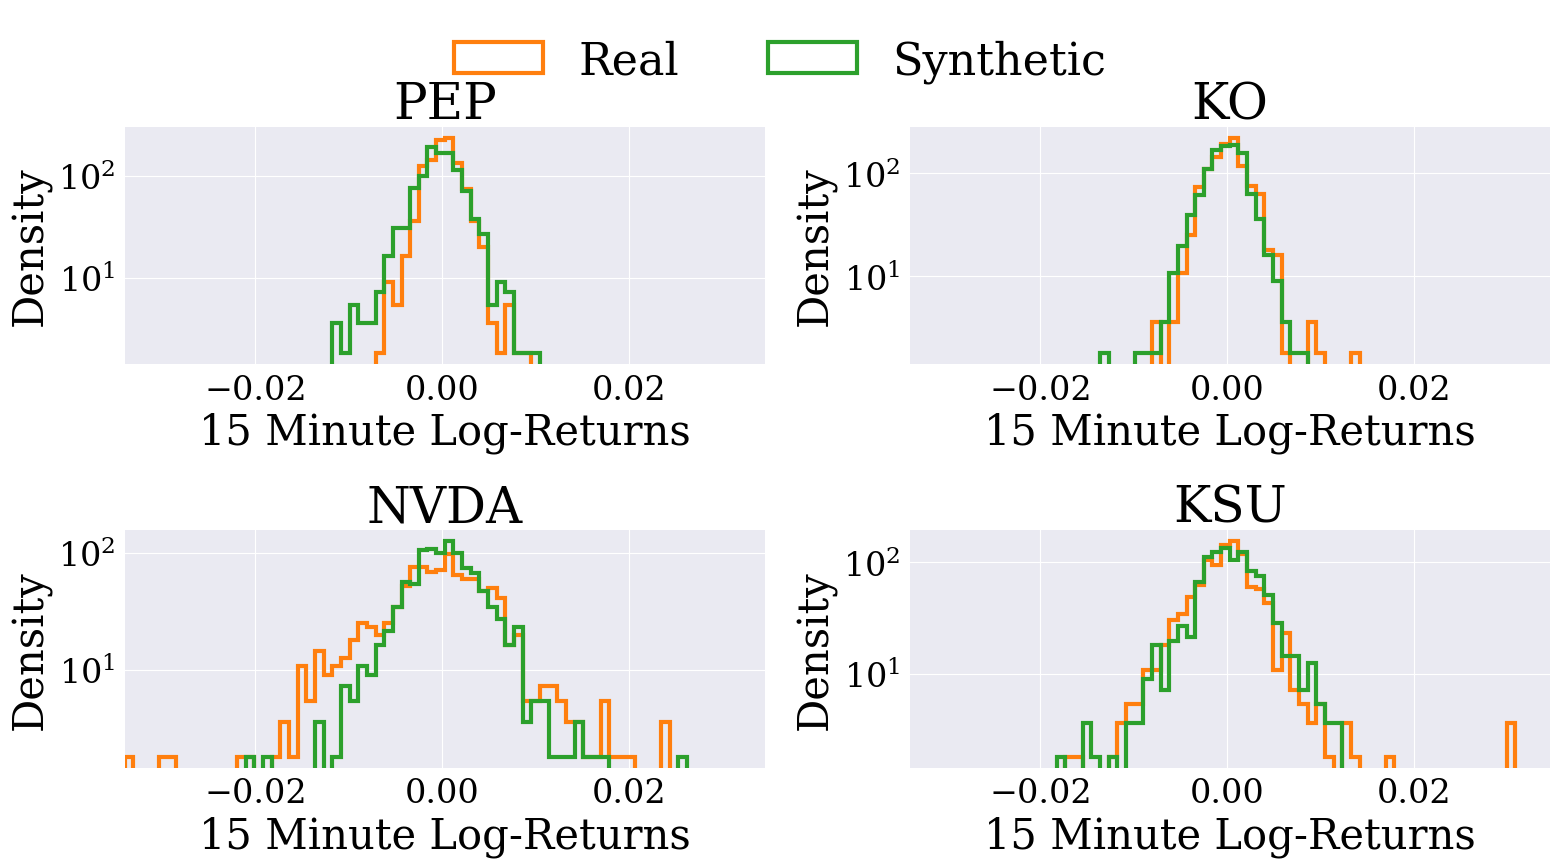

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

add_label = True
for ax, stock_name, real, synthetic in zip(axes, stock_names, n_minutely_returns_real, n_minutely_returns_synthetic):
    ax.set_xlim(xlim)

    ax.hist(
        x=[synthetic, real],
        label=["Synthetic", "Real"] if add_label else None,
        color=["C2", "C1"],
        bins=bins,
        density=True,
        log=True,
        histtype="step",
        linewidth=3,
    )

    add_label = False
    ax.set_title(f"{stock_name}", fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel(f"{n_minutes} Minute Log-Returns", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Density", fontsize=FONT_SIZE_LABEL)
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

# fig.suptitle("Aggregational Gaussianity", fontsize=FONT_SIZE_TITLE_PLOT, y=1.0)
fig.legend(
    loc="upper center",
    ncol=2,
    fontsize=FONT_SIZE_LEGEND,
    # bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig("plots/aggregational_gaussianity.pdf")
plt.show()
plt.close(fig)

## Absence of Autocorrelation

In [124]:
from numpy.lib.stride_tricks import sliding_window_view

In [125]:
minutely_returns_real.shape, minutely_returns_synthetic.shape

((4, 9336), (4, 9336))

In [126]:
window_shape = minutes_in_a_day
rolled_minutely_returns_real = sliding_window_view(minutely_returns_real, window_shape=window_shape, axis=1)
rolled_minutely_returns_synthetic = sliding_window_view(minutely_returns_synthetic, window_shape=window_shape, axis=1)
rolled_minutely_returns_real.shape, rolled_minutely_returns_synthetic.shape

((4, 8947, 390), (4, 8947, 390))

In [127]:
lags = [1, 10, 20, 30]
stock_name2lag2autocorr = dict()
for stock_name, real, synthetic in zip(stock_names, rolled_minutely_returns_real, rolled_minutely_returns_synthetic):
    lag2autocorr = dict()

    for lag in lags:
        l_real, l_synthetic = list(), list()

        for window_real, window_synthetic in zip(real, synthetic):
            autocorr_real = np.corrcoef(window_real[:-lag], window_real[lag:])[0, 1]
            autocorr_synthetic = np.corrcoef(window_synthetic[:-lag], window_synthetic[lag:])[0, 1]
            l_real.append(autocorr_real)
            l_synthetic.append(autocorr_synthetic)

        lag2autocorr[lag] = (np.asarray(l_real), np.asarray(l_synthetic))

    stock_name2lag2autocorr[stock_name] = lag2autocorr

In [128]:
bins = np.linspace(-1, 1, 50)

In [129]:
for stock_name, lag2autocorr in stock_name2lag2autocorr.items():
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    axes = axes.ravel()

    add_label = True
    for ax, (lag, (real, synthetic)) in zip(axes, lag2autocorr.items()):
        ax.set_xlim((-1, 1))

        ax.hist(
            x=[synthetic, real],
            label=["Synthetic", "Real"] if add_label else None,
            color=["C2", "C1"],
            bins=bins,
            density=True,
            log=True,
            histtype="step",
            linewidth=3,
        )

        add_label = False
        ax.set_title(f"Lag={lag}", fontsize=FONT_SIZE_TITLE_AX)
        ax.set_xlabel("Correlation Coefficient", fontsize=FONT_SIZE_LABEL)
        ax.set_ylabel("Density", fontsize=FONT_SIZE_LABEL)
        ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
        ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

        ax.set_facecolor('#eaeaf2')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(bottom=False, left=False, which='both')
        ax.grid(True, linestyle='solid', c='w')

    # fig.suptitle(f"Returns Autocorrelations {stock_name} - Window={window_shape}", fontsize=FONT_SIZE_TITLE_PLOT, y=1.0)
    fig.legend(
        loc="upper center",
        ncol=2,
        fontsize=FONT_SIZE_LEGEND,
        # bbox_to_anchor=(0.5, 1.06),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f"plots/absence_autocorrelation_{stock_name}.pdf")
    # plt.show()
    plt.close(fig)

## Volatility Clustering

In [130]:
price_real.shape, price_pred.shape

((4, 24, 390), (4, 24, 390))

In [131]:
window_shape = 20

windowed_price_real = sliding_window_view(price_real, window_shape=window_shape, axis=-1)
windowed_price_synthetic = sliding_window_view(price_pred, window_shape=window_shape, axis=-1)

rolled_volatility_real = (windowed_price_real.std(axis=-1) / np.sqrt(window_shape)).reshape(n_stocks, -1)
rolled_volatility_synthetic = (windowed_price_synthetic.std(axis=-1) / np.sqrt(window_shape)).reshape(n_stocks, -1)

rolled_volatility_real.shape, rolled_volatility_synthetic.shape

((4, 8904), (4, 8904))

In [132]:
x_indices, y_indices = [k1 for k1 in range(len(stock_names))], [
    k2 for k2 in range(len(stock_names), 2 * len(stock_names))
]

max_days = 11
lags = np.asarray(range(1, max_days)) * minutes_in_a_day

l_real, l_synthetic = list(), list()
for lag in lags:
    real = np.corrcoef(rolled_volatility_real[:, lag:], rolled_volatility_real[:, :-lag])[x_indices, y_indices]
    l_real.append(real)
    synthetic = np.corrcoef(rolled_volatility_synthetic[:, lag:], rolled_volatility_synthetic[:, :-lag])[
        x_indices, y_indices
    ]
    l_synthetic.append(synthetic)

corrs_real = np.asarray(l_real).T
corrs_synthetic = np.asarray(l_synthetic).T

corrs_real.shape, corrs_synthetic.shape

((4, 10), (4, 10))

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()

add_label = True
for ax, stock_name, real, synthetic in zip(axes, stock_names, corrs_real, corrs_synthetic):
    ax.plot(range(1, max_days), real, color="C1", linewidth=3, label="Real" if add_label else None)
    ax.plot(range(1, max_days), synthetic, color="C2", linewidth=3, label="Synthetic" if add_label else None)

    add_label = False
    ax.set_title(f"{stock_name}", fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel("Lag (Days)", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Correlation\nCoefficient", fontsize=FONT_SIZE_LABEL)
    ax.set_xticks(range(1, max_days))
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')


# fig.suptitle(f"Volatility clustering", fontsize=FONT_SIZE_TITLE_PLOT, y=1)
fig.legend(
    loc="upper center",
    ncol=2,
    fontsize=FONT_SIZE_LEGEND,
    # bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/volatility_clustering.pdf")
# plt.show()
plt.close(fig)

## Volume-Volatility Correlation

In [135]:
volume_real = volume_real.reshape(n_stocks, n_days, -1)
volume_synthetic = volume_pred.reshape(n_stocks, n_days, -1)

In [136]:
price_real.shape, volume_real.shape, price_real.shape, price_pred.shape

((4, 24, 390), (4, 24, 390), (4, 24, 390), (4, 24, 390))

In [137]:
window_shape = 30

In [138]:
# Volatility computed as standard deviation of the returns on a window W over square root of W

windowed_price_real = sliding_window_view(price_real, window_shape=window_shape, axis=-1)
windowed_price_synthetic = sliding_window_view(price_pred, window_shape=window_shape, axis=-1)
print(windowed_price_real.shape, windowed_price_synthetic.shape)

rolled_volatility_real = (windowed_price_real.std(axis=-1) / np.sqrt(window_shape)).reshape(n_stocks, -1)
rolled_volatility_synthetic = (windowed_price_synthetic.std(axis=-1) / np.sqrt(window_shape)).reshape(n_stocks, -1)

print(rolled_volatility_real.shape, rolled_volatility_synthetic.shape)

(4, 24, 361, 30) (4, 24, 361, 30)
(4, 8664) (4, 8664)


In [139]:
# Volatilty computed as square of the returns

rolled_volatility_real = np.square(price_real[:, :, window_shape - 1 :]).reshape((4, -1))
rolled_volatility_synthetic = np.square(price_pred[:, :, window_shape - 1 :]).reshape((4, -1))
rolled_volatility_real.shape, rolled_volatility_synthetic.shape

((4, 8664), (4, 8664))

In [140]:
windowed_volume_real = sliding_window_view(volume_real, window_shape=window_shape, axis=-1)
windowed_volume_synthetic = sliding_window_view(volume_synthetic, window_shape=window_shape, axis=-1)
print(windowed_volume_real.shape, windowed_volume_synthetic.shape)

rolled_mean_volume_real = (windowed_volume_real.mean(axis=-1)).reshape(n_stocks, -1)
rolled_mean_volume_synthetic = (windowed_volume_synthetic.mean(axis=-1)).reshape(n_stocks, -1)
print(rolled_mean_volume_real.shape, rolled_mean_volume_synthetic.shape)

(4, 24, 361, 30) (4, 24, 361, 30)
(4, 8664) (4, 8664)


In [141]:
window_shape = 390 * 2

windowed_rolled_volatility_real = sliding_window_view(rolled_volatility_real, window_shape=window_shape, axis=-1)
windowed_rolled_volatility_synthetic = sliding_window_view(
    rolled_volatility_synthetic, window_shape=window_shape, axis=-1
)
print(windowed_rolled_volatility_real.shape, windowed_rolled_volatility_synthetic.shape)

windowed_rolled_mean_volume_real = sliding_window_view(rolled_mean_volume_real, window_shape=window_shape, axis=-1)
windowed_rolled_mean_volume_synthetic = sliding_window_view(
    rolled_mean_volume_synthetic, window_shape=window_shape, axis=-1
)
print(windowed_rolled_mean_volume_real.shape, windowed_rolled_mean_volume_synthetic.shape)

(4, 7885, 780) (4, 7885, 780)
(4, 7885, 780) (4, 7885, 780)


In [142]:
d = dict()
for stock_name, real_volume, real_volatility, synthetic_volume, synthetic_volatility in zip(
    stock_names,
    windowed_rolled_mean_volume_real,
    windowed_rolled_volatility_real,
    windowed_rolled_mean_volume_synthetic,
    windowed_rolled_volatility_synthetic,
):
    l_real = list()
    for (
        window_volume,
        window_volatility,
    ) in zip(real_volume, real_volatility):
        real_corr = np.corrcoef(window_volume, window_volatility)[0, 1]
        l_real.append(real_corr)

    l_synthetic = list()
    for (
        window_volume,
        window_volatility,
    ) in zip(synthetic_volume, synthetic_volatility):
        synthetic_corr = np.corrcoef(window_volume, window_volatility)[0, 1]
        l_synthetic.append(synthetic_corr)

    d[stock_name] = (np.asarray(l_real), np.asarray(l_synthetic))

In [143]:
bins = np.linspace(-1, 1, 50)

In [145]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.ravel()
ns = list()
binss = list()
add_label = True
for ax, (stock_name, (corrs_real, corrs_synthetic)) in zip(axes, d.items()):
    ax.set_xlim((-1, 1))

    n, bins, _ = ax.hist(
        x=[corrs_synthetic, corrs_real],
        label=["Synthetic", "Real"] if add_label else None,
        color=["C2", "C1"],
        bins=bins,
        density=True,
        log=True,
        histtype="step",
        linewidth=3,
    )
    ns.append(n)
    binss.append(bins)

    add_label = False
    ax.set_title(f"{stock_name}", fontsize=FONT_SIZE_TITLE_AX)
    ax.set_xlabel("Correlation Coefficient", fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel("Density", fontsize=FONT_SIZE_LABEL)
    ax.xaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)
    ax.yaxis.set_tick_params(labelsize=FONT_SIZE_TICKS)

    ax.set_facecolor('#eaeaf2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(bottom=False, left=False, which='both')
    ax.grid(True, linestyle='solid', c='w')

# fig.suptitle(f"Volume-Volatility Correlation Window={window_shape}", fontsize=FONT_SIZE_TITLE_PLOT, y=1)
fig.legend(
    loc="upper center",
    ncol=2,
    fontsize=FONT_SIZE_LEGEND,
    # bbox_to_anchor=(0.5, 1.06),
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("plots/volume_volatility_correlation.pdf")
# plt.show()
plt.close(fig)